# Regression example using PT-MELT
This is a basic regression example using the models in PT-MELT.

Requires the following additional packages:
* ipykernel
* scikit-learn
* matplotlib
* torchinfo

In [1]:
import sklearn.datasets as sdt
import matplotlib.pyplot as plt

# Create surogate data
n_samples = 1000
n_features = 10
n_info = 5
n_targets = 3
noise = 10

x, y = sdt.make_regression(
    n_samples=n_samples,
    n_features=n_features,
    n_informative=n_info,
    n_targets=n_targets,
    noise=noise,
    random_state=42,
)
print(f"Shape of x: {x.shape}, Shape of y: {y.shape}")

Shape of x: (1000, 10), Shape of y: (1000, 3)


In [2]:
# Use sklearn scaling libraries to normalize the data
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

x_normalizer = StandardScaler()
y_normalizer = StandardScaler()

x_normalizer.fit(x)
y_normalizer.fit(y)

x_norm = x_normalizer.transform(x)
y_norm = y_normalizer.transform(y)

# Create train and test datasets
x_train, x_test, y_train, y_test = train_test_split(
    x_norm, y_norm, test_size=0.2, random_state=42
)
# Create the validation dataset from the test dataset
x_test, x_val, y_test, y_val = train_test_split(
    x_test, y_test, test_size=0.5, random_state=42
)

# Precompute the un-normalized data for later use
y_train_real = y_normalizer.inverse_transform(y_train)
y_test_real = y_normalizer.inverse_transform(y_test)
y_val_real = y_normalizer.inverse_transform(y_val)

# Hyperparameters
Set consistent hyperparameters for all models for comparisons sake.

In [3]:
# General hyperparameters
n_epochs = 300
batch_size = 32
loss = "mse"
learn_rate = 1e-3
l1_reg = 0
l2_reg = 0
act_fun = "relu"
dropout = 0.1
input_dropout = 0.1
batch_norm = False
batch_norm_type = "ema"
output_activation = "linear"

width = 8
depth = 2

# ResNet specific hyperparameters
layers_per_block = 4

# Make a history dict for storing metrics
history = {"loss": [], "val_loss": []}

## Artificial Neural Network (ANN)
Create and train an ANN using PT-MELT.

In [4]:
from ptmelt.models import ArtificialNeuralNetwork
from torchinfo import summary
import torch
from torch import optim


# Create the model
ann_model = ArtificialNeuralNetwork(
    num_features=n_features,
    num_outputs=n_targets,
    width=width,
    depth=depth,
    act_fun=act_fun,
    l1_reg=l1_reg,
    l2_reg=l2_reg,
    input_dropout=input_dropout,
    dropout=dropout,
    batch_norm=batch_norm,
    batch_norm_type=batch_norm_type,
    output_activation=output_activation,
)


# Build the model and print the summary
ann_model.build()
print(summary(ann_model, input_size=(1, n_features)))

# Define the loss function and optimizer for training
criterion = ann_model.get_loss_fn(loss="mse", reduction="mean")
optimizer = optim.Adam(ann_model.parameters(), lr=learn_rate)

Layer (type:depth-idx)                   Output Shape              Param #
ArtificialNeuralNetwork                  [1, 3]                    --
├─ModuleDict: 1-1                        --                        --
│    └─Dropout: 2-1                      [1, 10]                   --
│    └─DenseBlock: 2-2                   [1, 8]                    --
│    │    └─ModuleDict: 3-1              --                        160
│    └─DefaultOutput: 2-3                [1, 3]                    --
│    │    └─Linear: 3-2                  [1, 3]                    27
│    │    └─Identity: 3-3                [1, 3]                    --
Total params: 187
Trainable params: 187
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00


In [5]:
import torch
from torch.utils.data import DataLoader, TensorDataset

# Create the data holder for training/validation (the test set should be held separate from any model training)
dataset = TensorDataset(
    torch.from_numpy(x_train).float(), torch.from_numpy(y_train).float()
)
dataset_val = TensorDataset(
    torch.from_numpy(x_val).float(), torch.from_numpy(y_val).float()
)

dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
dataloader_val = DataLoader(dataset_val, batch_size=batch_size, shuffle=True)

In [6]:
# Fit the model using the built-in training loop
ann_model.fit(
    train_dl=dataloader,
    val_dl=dataloader_val,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=n_epochs,
)

history = ann_model.history

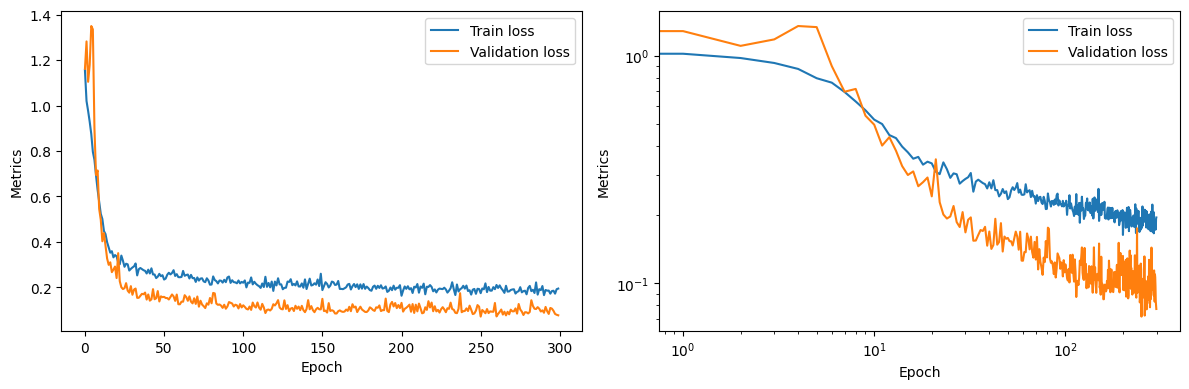

In [7]:
from ptmelt.utils.visualization import plot_history

# Plot the training history
plot_history(history, metrics=["loss"], plot_log=True)

In [8]:
from ptmelt.utils.evaluation import make_predictions

# Evaluate the model performance on train, validation, and test data
pred_train = make_predictions(
    ann_model, x_train, y_normalizer=y_normalizer, unnormalize=True
)
pred_val = make_predictions(
    ann_model, x_val, y_normalizer=y_normalizer, unnormalize=True
)
pred_test = make_predictions(
    ann_model, x_test, y_normalizer=y_normalizer, unnormalize=True
)

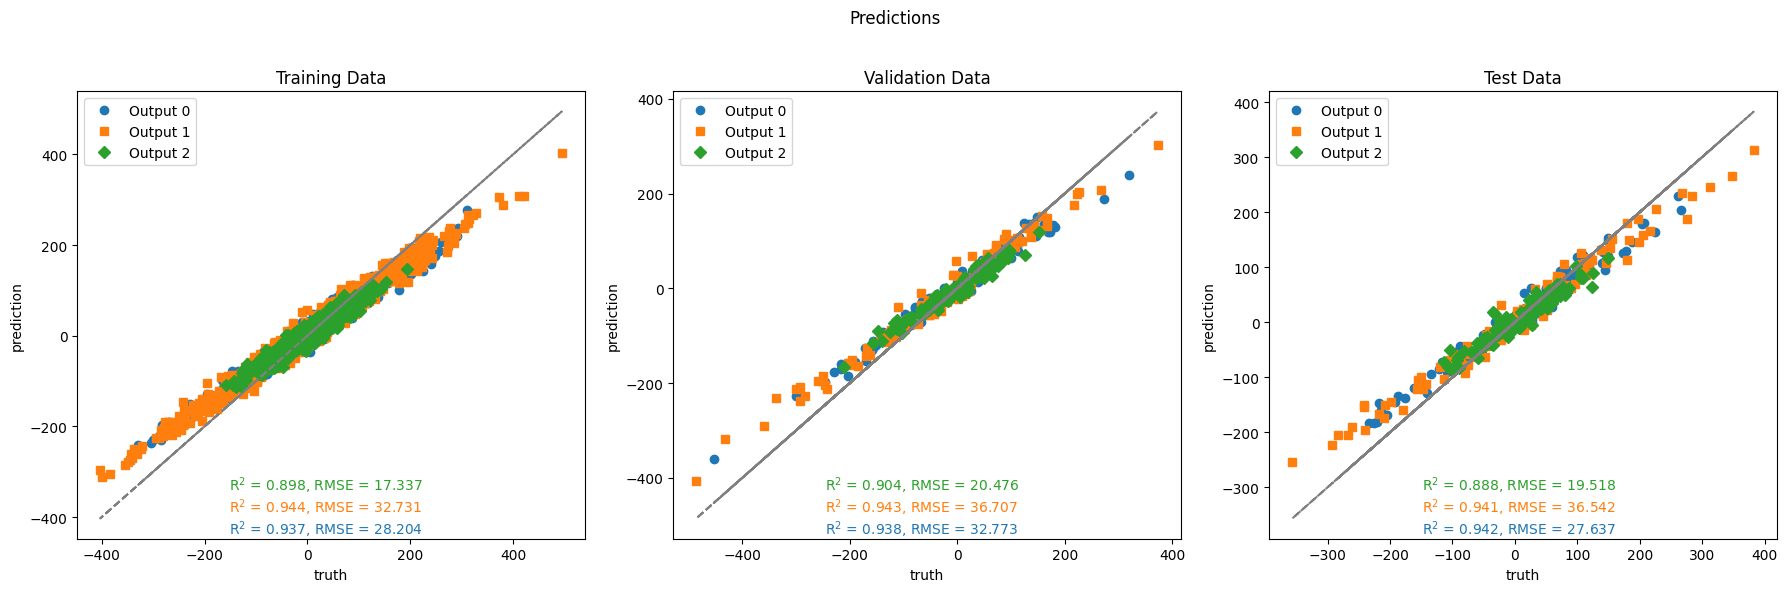

In [9]:
from ptmelt.utils.visualization import plot_predictions

# Plot the predictions
plot_predictions(pred_train, y_train_real, pred_val, y_val_real, pred_test, y_test_real)

In [10]:
from ptmelt.utils.evaluation import ensemble_predictions

# Make ensemble predictions using MC Dropout
n_iter = 100
pred_train_mean, pred_train_std = ensemble_predictions(
    ann_model,
    x_train,
    y_normalizer=y_normalizer,
    unnormalize=True,
    n_iter=n_iter,
    training=True,
)
pred_val_mean, pred_val_std = ensemble_predictions(
    ann_model,
    x_val,
    y_normalizer=y_normalizer,
    unnormalize=True,
    n_iter=n_iter,
    training=True,
)
pred_test_mean, pred_test_std = ensemble_predictions(
    ann_model,
    x_test,
    y_normalizer=y_normalizer,
    unnormalize=True,
    n_iter=n_iter,
    training=True,
)

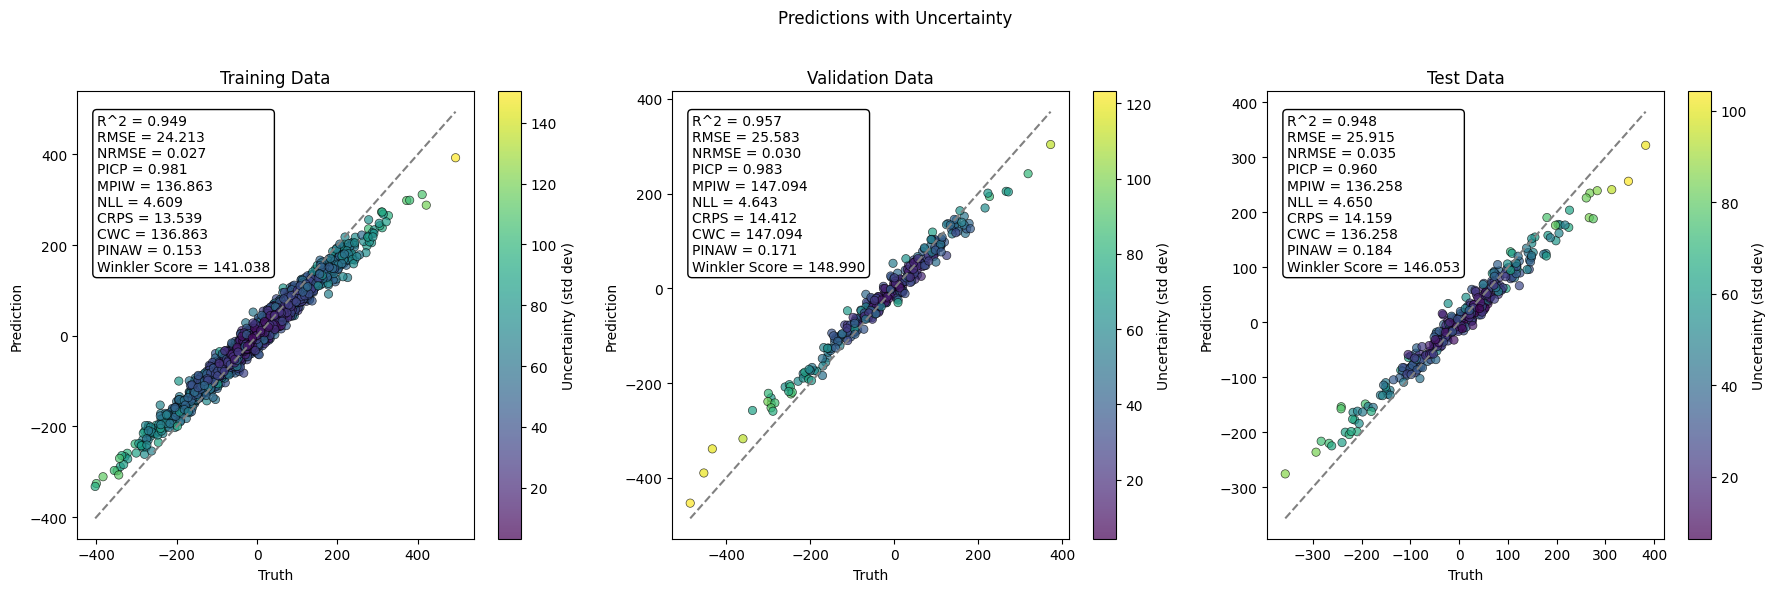

In [11]:
from ptmelt.utils.visualization import plot_predictions_with_uncertainty

# Plot MC Dropout predictions
plot_predictions_with_uncertainty(
    pred_train_mean,
    pred_train_std,
    y_train_real,
    pred_val_mean,
    pred_val_std,
    y_val_real,
    pred_test_mean,
    pred_test_std,
    y_test_real,
    metrics_to_display=None,  # Display all metrics
)

## Residual Neural Network (ResNet)
Create and train a ResNet using PT-MELT.

In [12]:
from ptmelt.models import ResidualNeuralNetwork

# Create the model
resnet_model = ResidualNeuralNetwork(
    num_features=n_features,
    num_outputs=n_targets,
    width=width,
    depth=depth,
    layers_per_block=layers_per_block,
    act_fun=act_fun,
    l1_reg=l1_reg,
    l2_reg=l2_reg,
    input_dropout=input_dropout,
    dropout=dropout,
    batch_norm=batch_norm,
    batch_norm_type=batch_norm_type,
    pre_activation=True,
    post_add_activation=False,
    output_activation=output_activation,
)

# Build the model and print the summary
resnet_model.build()
print(summary(resnet_model, input_size=(1, n_features)))

# Define the loss function and optimizer for training
criterion = resnet_model.get_loss_fn(loss="mse", reduction="mean")
optimizer = optim.Adam(resnet_model.parameters(), lr=learn_rate)

Layer (type:depth-idx)                   Output Shape              Param #
ResidualNeuralNetwork                    [1, 3]                    --
├─ModuleDict: 1-1                        --                        --
│    └─Dropout: 2-1                      [1, 10]                   --
│    └─ResidualBlock: 2-2                [1, 8]                    --
│    │    └─ModuleDict: 3-1              --                        160
│    └─DefaultOutput: 2-3                [1, 3]                    --
│    │    └─Linear: 3-2                  [1, 3]                    27
│    │    └─Identity: 3-3                [1, 3]                    --
Total params: 187
Trainable params: 187
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00


/Users/nwimer/NREL_Repos/pt-melt/ptmelt/models.py:401: UserWarning: Warning: depth 2 is not divisible by layers_per_block (4), so the last block will have 2 layers.
  warnings.warn(
/Users/nwimer/NREL_Repos/pt-melt/ptmelt/blocks.py:200: UserWarning: Warning: Number of layers 2 is not divisible by layers_per_block (4), so the last block will have 2 layers.
  warnings.warn(


In [13]:
# Fit the model using the built-in training loop
resnet_model.fit(
    train_dl=dataloader,
    val_dl=dataloader_val,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=n_epochs,
)

history = resnet_model.history

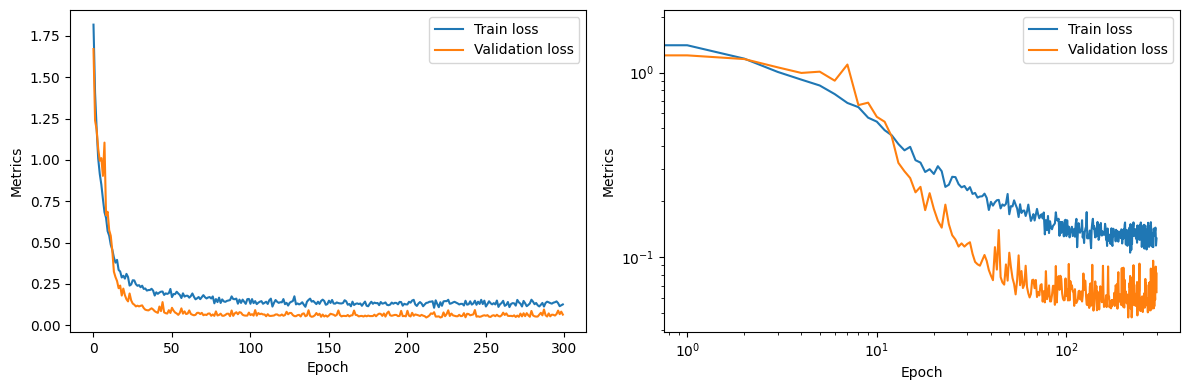

In [14]:
from ptmelt.utils.visualization import plot_history

# Plot the training history
plot_history(history, metrics=["loss"], plot_log=True)

In [15]:
from ptmelt.utils.evaluation import make_predictions

# Evaluate the model performance on train, validation, and test data
pred_train = make_predictions(
    resnet_model, x_train, y_normalizer=y_normalizer, unnormalize=True
)
pred_val = make_predictions(
    resnet_model, x_val, y_normalizer=y_normalizer, unnormalize=True
)
pred_test = make_predictions(
    resnet_model, x_test, y_normalizer=y_normalizer, unnormalize=True
)

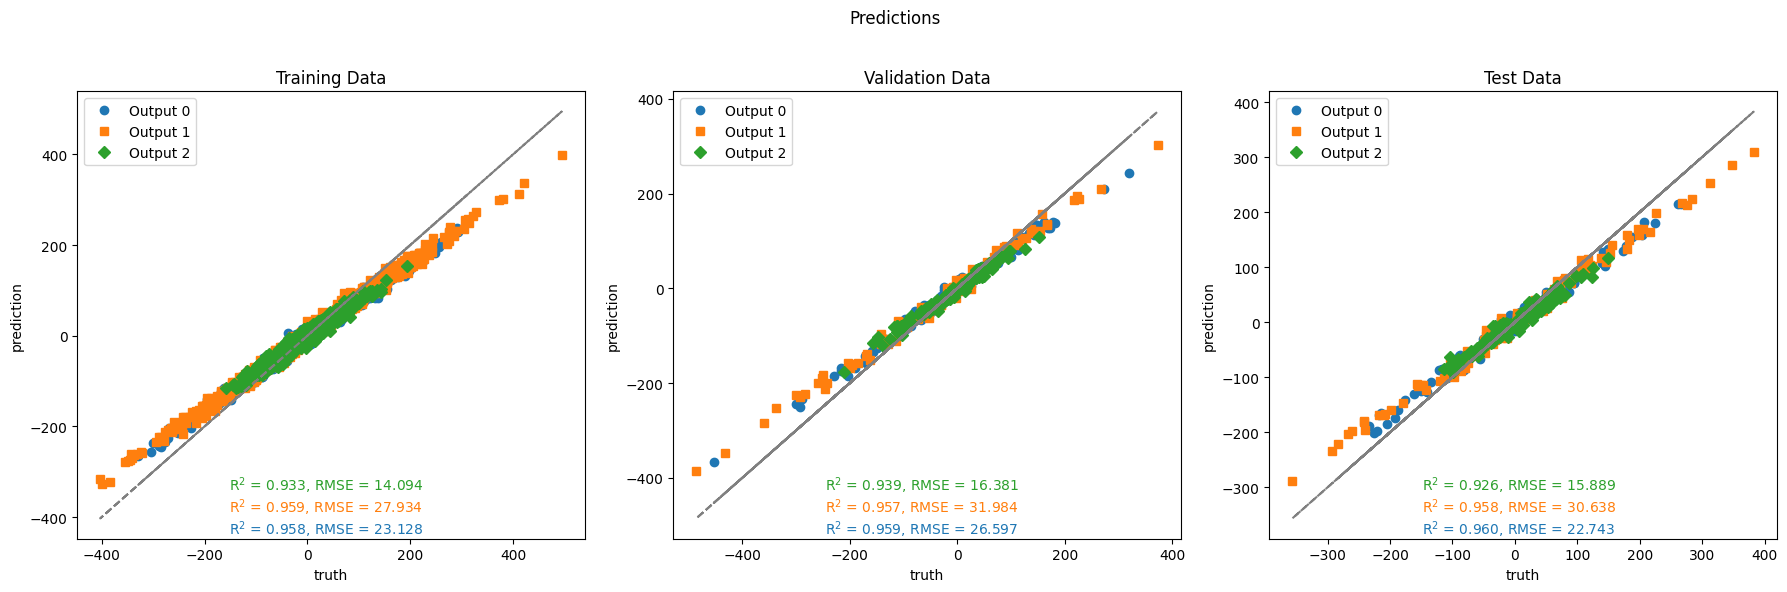

In [16]:
from ptmelt.utils.visualization import plot_predictions

# Plot the predictions
plot_predictions(pred_train, y_train_real, pred_val, y_val_real, pred_test, y_test_real)

In [17]:
from ptmelt.utils.evaluation import ensemble_predictions

# Make ensemble predictions using MC Dropout
n_iter = 100
pred_train_mean, pred_train_std = ensemble_predictions(
    resnet_model,
    x_train,
    y_normalizer=y_normalizer,
    unnormalize=True,
    n_iter=n_iter,
    training=True,
)
pred_val_mean, pred_val_std = ensemble_predictions(
    resnet_model,
    x_val,
    y_normalizer=y_normalizer,
    unnormalize=True,
    n_iter=n_iter,
    training=True,
)
pred_test_mean, pred_test_std = ensemble_predictions(
    resnet_model,
    x_test,
    y_normalizer=y_normalizer,
    unnormalize=True,
    n_iter=n_iter,
    training=True,
)

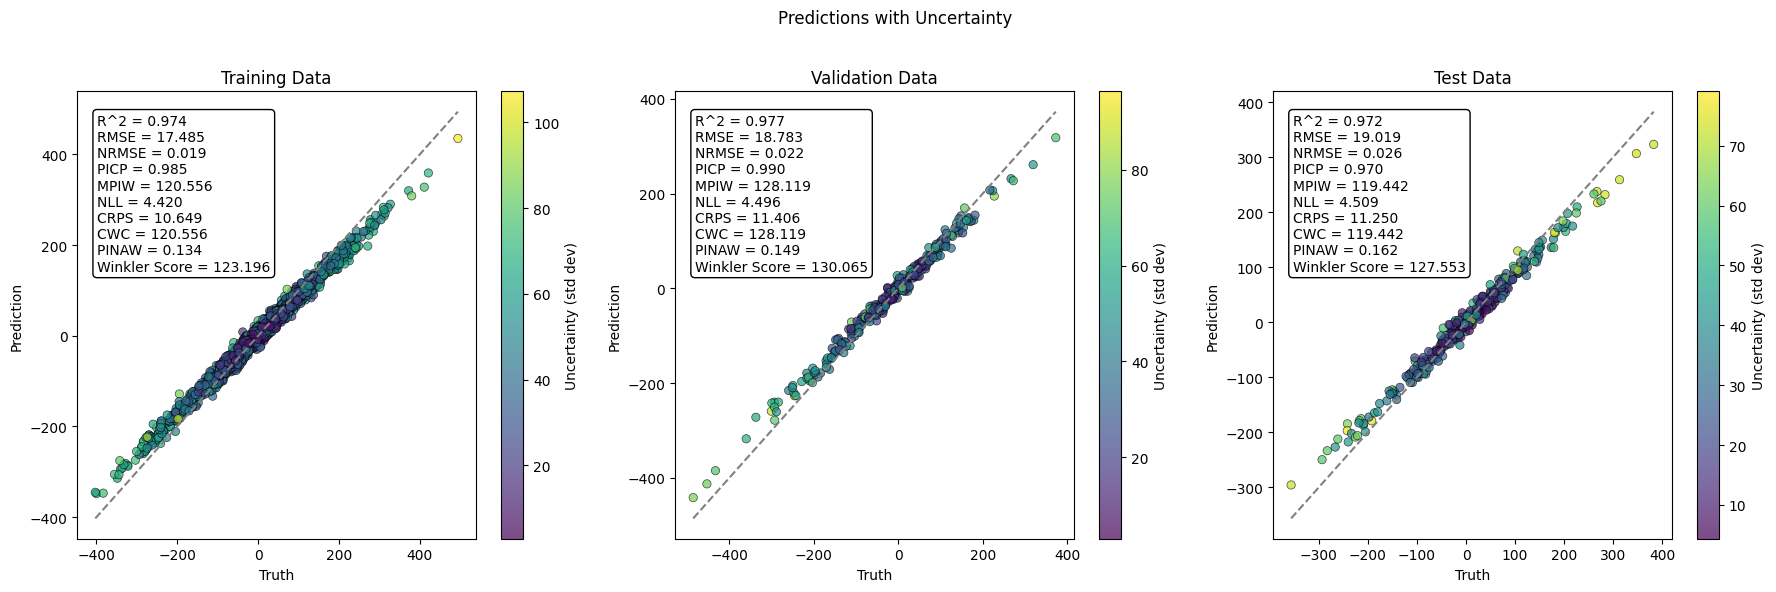

In [18]:
from ptmelt.utils.visualization import plot_predictions_with_uncertainty

# Plot MC Dropout predictions
plot_predictions_with_uncertainty(
    pred_train_mean,
    pred_train_std,
    y_train_real,
    pred_val_mean,
    pred_val_std,
    y_val_real,
    pred_test_mean,
    pred_test_std,
    y_test_real,
    metrics_to_display=None,  # Display all metrics
)

# Mixture Density Network

Test the MDN with varying numbers of mixtures (when mixtures=1, it is a heteroscedastic NN)

In [19]:
from ptmelt.models import ArtificialNeuralNetwork
from torchinfo import summary
from torch import nn, optim

# Create the model
mdn_model = ArtificialNeuralNetwork(
    num_features=n_features,
    num_outputs=n_targets,
    width=width,
    depth=depth,
    act_fun=act_fun,
    l1_reg=l1_reg,
    l2_reg=l2_reg,
    input_dropout=0.0,  # Remove input dropout
    dropout=0.0,  # Remove dropout
    batch_norm=batch_norm,
    batch_norm_type=batch_norm_type,
    output_activation=output_activation,
    num_mixtures=1,
)

# Build the model and print the summary
mdn_model.build()
print(summary(mdn_model, input_size=(1, n_features)))

# Define the loss function and optimizer for training
criterion = mdn_model.get_loss_fn()
optimizer = optim.Adam(mdn_model.parameters(), lr=learn_rate)

Layer (type:depth-idx)                   Output Shape              Param #
ArtificialNeuralNetwork                  [1, 7]                    --
├─ModuleDict: 1-1                        --                        --
│    └─DenseBlock: 2-1                   [1, 8]                    --
│    │    └─ModuleDict: 3-1              --                        160
│    └─MixtureDensityOutput: 2-2         [1, 7]                    --
│    │    └─Linear: 3-2                  [1, 1]                    9
│    │    └─Softmax: 3-3                 [1, 1]                    --
│    │    └─Linear: 3-4                  [1, 3]                    27
│    │    └─Linear: 3-5                  [1, 3]                    27
Total params: 223
Trainable params: 223
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00


/Users/nwimer/NREL_Repos/pt-melt/ptmelt/models.py:206: UserWarning: Mixture Density Networks require the use of the MixtureDensityLoss class. The loss function will be set to automatically.
  warnings.warn(


In [20]:
# Fit the model using the built-in training loop
mdn_model.fit(
    train_dl=dataloader,
    val_dl=dataloader_val,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=n_epochs,
)

history = mdn_model.history

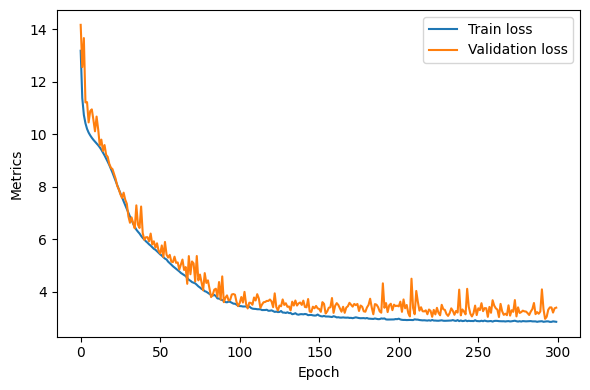

In [21]:
from ptmelt.utils.visualization import plot_history

# Plot the training history
plot_history(history, metrics=["loss"], plot_log=False)

In [22]:
from ptmelt.utils.evaluation import make_predictions

# Evaluate the model performance on train, validation, and test data
pred_train, pred_train_std = make_predictions(
    mdn_model, x_train, y_normalizer=y_normalizer, unnormalize=True
)
pred_val, pred_val_std = make_predictions(
    mdn_model, x_val, y_normalizer=y_normalizer, unnormalize=True
)
pred_test, pred_test_std = make_predictions(
    mdn_model, x_test, y_normalizer=y_normalizer, unnormalize=True
)

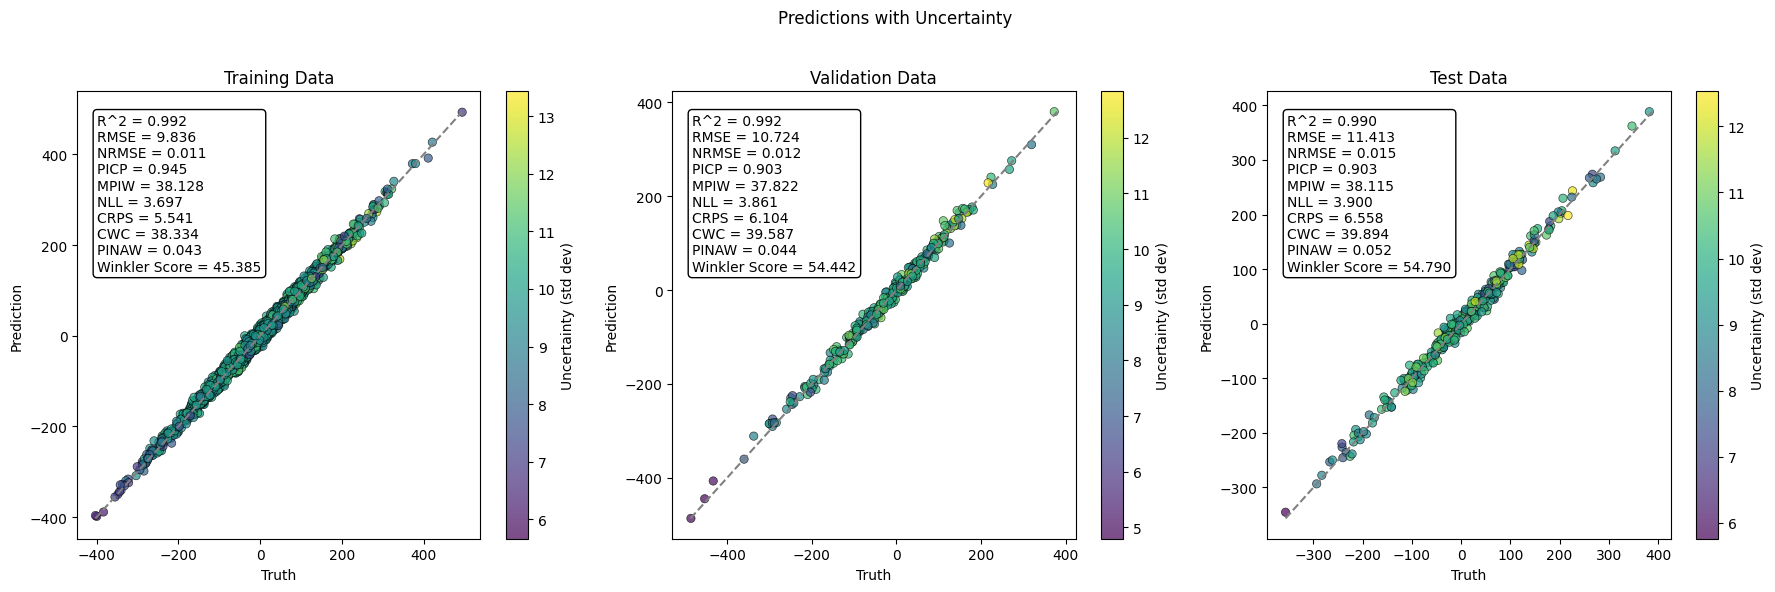

In [23]:
from ptmelt.utils.visualization import plot_predictions_with_uncertainty

# Plot the predictions
plot_predictions_with_uncertainty(
    pred_train,
    pred_train_std,
    y_train_real,
    pred_val,
    pred_val_std,
    y_val_real,
    pred_test,
    pred_test_std,
    y_test_real,
    metrics_to_display=None,  # Display all metrics
)

# Bayesian Neural Network (BNN)


## Epistemic Uncertainty Predictions
We will turn off the aleatoric output layer and instead train an epistemic BNN model (of varying number of layers). Predictions will be made using Monte Carlo methods.

In [24]:
import torch
from torch.utils.data import DataLoader, TensorDataset

# Create the data holder for training/validation (the test set should be held separate from any model training)
dataset = TensorDataset(
    torch.from_numpy(x_train).float(), torch.from_numpy(y_train).float()
)
dataset_val = TensorDataset(
    torch.from_numpy(x_val).float(), torch.from_numpy(y_val).float()
)

dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
dataloader_val = DataLoader(dataset_val, batch_size=batch_size, shuffle=True)

In [25]:
from ptmelt.models import BayesianNeuralNetwork
from torchinfo import summary
from torch import nn, optim

# Create the model
bnn_model = BayesianNeuralNetwork(
    num_features=n_features,
    num_outputs=n_targets,
    width=width,
    depth=depth,
    act_fun=act_fun,
    l1_reg=l1_reg,
    l2_reg=l2_reg,
    input_dropout=0.0,  # Remove input dropout
    dropout=0.0,  # Remove dropout
    batch_norm=batch_norm,
    batch_norm_type=batch_norm_type,
    output_activation=output_activation,
    # num_mixtures=0,
)

# Build the model and print the summary
bnn_model.build()
# print(summary(bnn_model, input_size=(1, n_features)))

# Define the loss function and optimizer for training
criterion = bnn_model.get_loss_fn()
optimizer = optim.Adam(bnn_model.parameters(), lr=learn_rate)

In [26]:
# Fit the model using the built-in training loop
bnn_model.fit(
    train_dl=dataloader,
    val_dl=dataloader_val,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=n_epochs,
    verbose=True,
)

history = bnn_model.history

  5%|▍         | 14/300 [00:00<00:07, 39.98it/s]

Epoch 10, Loss: 1.7403, Val Loss: 8.3226


  8%|▊         | 24/300 [00:00<00:06, 40.90it/s]

Epoch 20, Loss: 1.0587, Val Loss: 7.2393


 11%|█▏        | 34/300 [00:00<00:06, 41.44it/s]

...

Epoch 280, Loss: 0.3726, Val Loss: 2.6174


 98%|█████████▊| 294/300 [00:07<00:00, 42.61it/s]

Epoch 290, Loss: 0.3651, Val Loss: 2.5171


100%|██████████| 300/300 [00:07<00:00, 41.17it/s]

Epoch 300, Loss: 0.3517, Val Loss: 2.4344


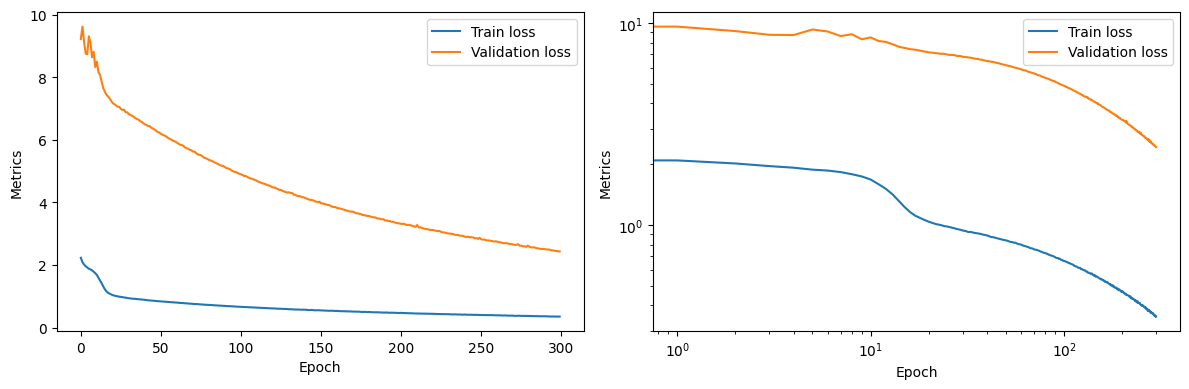

In [27]:
from ptmelt.utils.visualization import plot_history

# Plot the training history
plot_history(history, metrics=["loss"], plot_log=True)

In [28]:
from ptmelt.utils.evaluation import ensemble_predictions

# Make ensemble predictions using MC Dropout
n_iter = 100
pred_train_mean, pred_train_std = ensemble_predictions(
    bnn_model,
    x_train,
    y_normalizer=y_normalizer,
    unnormalize=True,
    n_iter=n_iter,
    training=True,
)
pred_val_mean, pred_val_std = ensemble_predictions(
    bnn_model,
    x_val,
    y_normalizer=y_normalizer,
    unnormalize=True,
    n_iter=n_iter,
    training=True,
)
pred_test_mean, pred_test_std = ensemble_predictions(
    bnn_model,
    x_test,
    y_normalizer=y_normalizer,
    unnormalize=True,
    n_iter=n_iter,
    training=True,
)

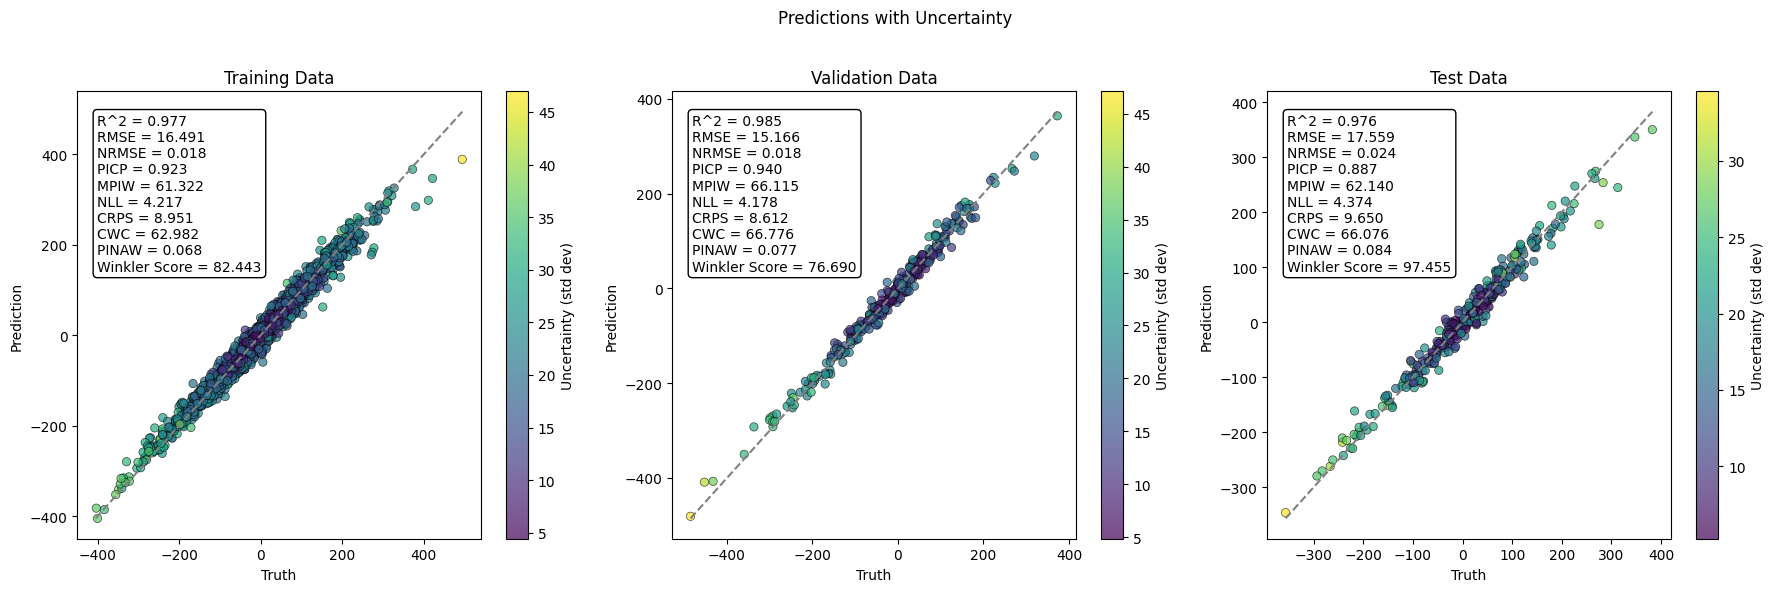

In [29]:
from ptmelt.utils.visualization import plot_predictions_with_uncertainty

# Plot MC Dropout predictions
plot_predictions_with_uncertainty(
    pred_train_mean,
    pred_train_std,
    y_train_real,
    pred_val_mean,
    pred_val_std,
    y_val_real,
    pred_test_mean,
    pred_test_std,
    y_test_real,
    metrics_to_display=None,  # Display all metrics
)